Dataset Preview
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  

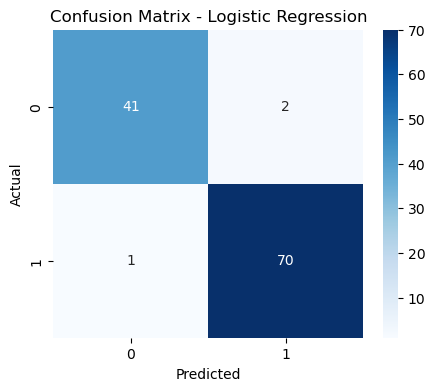


MODEL: Random Forest
Accuracy : 0.9649122807017544
Precision: 0.958904109589041
Recall   : 0.9859154929577465
F1 Score : 0.9722222222222222
ROC-AUC  : 0.995250573206682

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



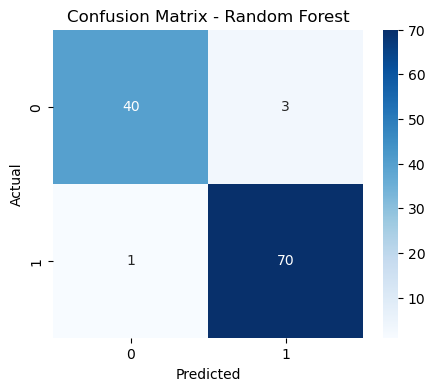


Cross Validation Accuracy
Logistic Regression CV Accuracy: 0.9806862288464524
Random Forest CV Accuracy: 0.9560937742586555


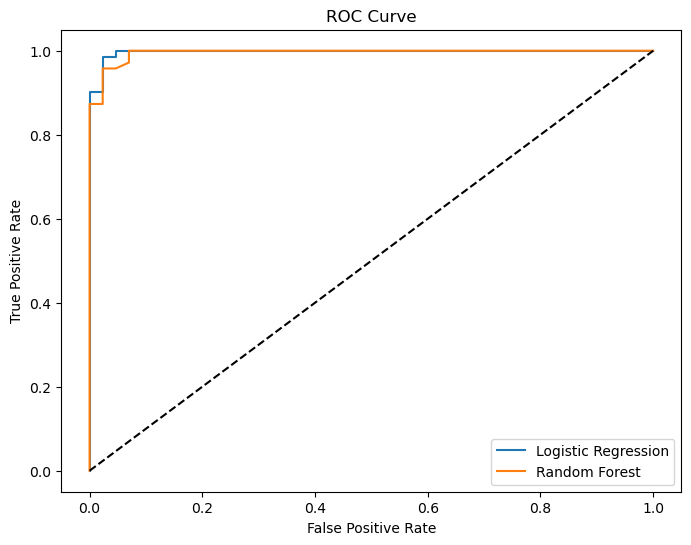


Final Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.973684   0.972222  0.985915  0.979021  0.997380
1        Random Forest  0.964912   0.958904  0.985915  0.972222  0.995251


In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import load_breast_cancer


from sklearn.preprocessing import StandardScaler


from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve


# Load Breast Cancer Datase
data = load_breast_cancer()

# Convert into DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add Target Column
df['target'] = data.target

# Display first 5 rows
print("Dataset Preview")
print(df.head())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


log_model = LogisticRegression()

log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Probability Scores
y_prob_log = log_model.predict_proba(X_test)[:,1]


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Probability Scores
y_prob_rf = rf_model.predict_proba(X_test)[:,1]


def evaluate_model(y_test, y_pred, y_prob, model_name):

    print("\n=================================")
    print("MODEL:", model_name)
    print("=================================")

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC-AUC  :", roc_auc)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return accuracy, precision, recall, f1, roc_auc


log_results = evaluate_model(
    y_test,
    y_pred_log,
    y_prob_log,
    "Logistic Regression"
)

rf_results = evaluate_model(
    y_test,
    y_pred_rf,
    y_prob_rf,
    "Random Forest"
)


log_cv = cross_val_score(
    log_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

rf_cv = cross_val_score(
    rf_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("\nCross Validation Accuracy")

print("Logistic Regression CV Accuracy:",
      log_cv.mean())

print("Random Forest CV Accuracy:",
      rf_cv.mean())


# Logistic Regression ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log,
         label='Logistic Regression')

plt.plot(fpr_rf, tpr_rf,
         label='Random Forest')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_results[0], rf_results[0]],
    'Precision': [log_results[1], rf_results[1]],
    'Recall': [log_results[2], rf_results[2]],
    'F1 Score': [log_results[3], rf_results[3]],
    'ROC-AUC': [log_results[4], rf_results[4]]
})

print("\nFinal Model Comparison")
print(results_df)

